In [249]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from tabulate import tabulate

os.environ['PATH'] += ':/Library/TeX/texbin'

plt.rcParams.update({
    "text.usetex": True,
})

In [250]:
results_paths: dict = {
    "ablation_dense": {
        "no_entropy": "../data/exp1_ablation_dense_no_entropy.csv",
        "entropy": "../data/exp1_ablation_dense_entropy.csv"
    },
    "ablation_sparse": {
        "no_entropy": "../data/exp1_ablation_sparse_no_entropy.csv",
        "entropy": "../data/exp1_ablation_sparse_entropy.csv"
    },
    "toysim": {
        "no_entropy": "../data/exp1_toymap_no_entropy.csv",
        "entropy": "../data/exp1_toymap_entropy.csv"
    }
}

In [251]:
# Validate that all paths are correct
for dataset, values in results_paths.items():
    for entropy, path in values.items():
        try:
            pd.read_csv(path)
        except FileNotFoundError:
            print(f"File not found: {path}")
            exit(1)

In [252]:
# load all data
data_frames = {}
for dataset, values in results_paths.items():
    data_frames[dataset] = {}
    for entropy, path in values.items():
        df = pd.read_csv(path)
        
        # remove all columns with only one unique value
        df_filtered = df.loc[:, df.nunique() > 1]
        
        data_frames[dataset][entropy] = df_filtered

print(f"Data Keys: {data_frames.keys()}")
print(f"Data Values: {data_frames[list(data_frames.keys())[0]].keys()}")

Data Keys: dict_keys(['ablation_dense', 'ablation_sparse', 'toysim'])
Data Values: dict_keys(['no_entropy', 'entropy'])


In [253]:
print(data_frames["ablation_dense"]["no_entropy"].head())

   Unnamed: 0  test_nll  test_auc          decoding_method  axis_resolution  \
0           0  0.484939  0.939412                     relu              0.1   
1           1  0.504697  0.903999           relu_normalize              0.1   
2           2  0.617697  0.937240            relu_squaring              0.1   
3           3  0.562121  0.936633  relu_normalize_squaring              0.1   
4           4  0.494273  0.916347                     tanh              0.1   

   vector_length_scale  vector_dimensionality  
0                  0.1                  32768  
1                  0.1                  32768  
2                  0.1                  32768  
3                  0.1                  32768  
4                  0.1                  32768  


---
### Plot the distribution of the AUC and NLL across each dataset
---

In [254]:
# Load data into a structured format
box_plot_data = []
for dataset, entropy_config in data_frames.items():
    for entropy, df in entropy_config.items():
        for _, row in df.iterrows():
            box_plot_data.append({
                "Dataset": dataset,
                "Entropy": entropy,
                "Dataset_Entropy": f"{dataset}",
                "NLL": row["test_nll"],
                "AUC": row["test_auc"]
            })
box_plot_dataframe = pd.DataFrame(box_plot_data)
print(box_plot_dataframe.columns)
box_plot_dataframe.head()

Index(['Dataset', 'Entropy', 'Dataset_Entropy', 'NLL', 'AUC'], dtype='object')


,Dataset,Entropy,Dataset_Entropy,NLL,AUC
0,ablation_dense,no_entropy,ablation_dense,0.484939,0.939412
1,ablation_dense,no_entropy,ablation_dense,0.504697,0.903999
2,ablation_dense,no_entropy,ablation_dense,0.617697,0.937240
3,ablation_dense,no_entropy,ablation_dense,0.562121,0.936633
4,ablation_dense,no_entropy,ablation_dense,0.494273,0.916347


In [255]:
def print_statistics_entropy(df: pd.DataFrame, metric: str):
    summary_stats = df.groupby(['Dataset', 'Entropy'])[metric].describe()[['25%', '50%', '75%', 'min', 'max', 'mean', 'std']]
    summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']

    # Reset index for tabulate
    summary_stats.reset_index(inplace=True)

    # Print formatted table
    print(tabulate(summary_stats, headers='keys', tablefmt='pretty', floatfmt=".4f"))

+---+-----------------+------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
|   |     Dataset     |  Entropy   |         25%         |         50%         |        75%         |        min         |        max         |        mean         |         std         |         IQR         |
+---+-----------------+------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
| 0 | ablation_dense  |  entropy   | 0.45544113598972136 | 0.6449198771740572  | 0.9641232288685699 | 0.1256398450819784 | 18.03537694019358  |  2.737341782398774  |  5.280090583239908  | 0.5086820928788486  |
| 1 | ablation_dense  | no_entropy | 0.3470982571750274  | 0.48504692684149764 | 0.6181807823271499 | 0.2592069773683494 | 0.9034236744887204 | 0.49174271546672

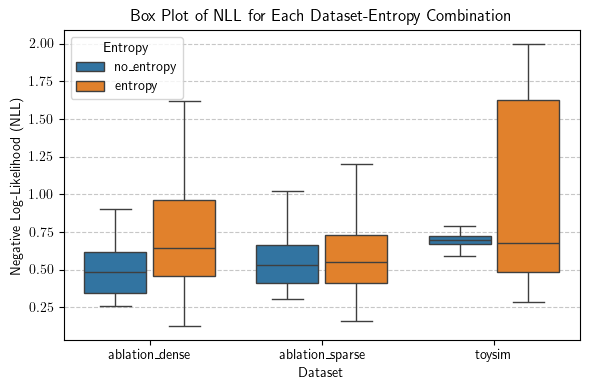

In [256]:
plt.figure(figsize=(6, 4))

print_statistics_entropy(box_plot_dataframe, 'NLL')

sns.boxplot(x='Dataset_Entropy', y="NLL", data=box_plot_dataframe, hue="Entropy", showfliers=False, dodge=True, gap=0.1)


# Improve readability
# plt.xticks(rotation=45, ha="right")
plt.xlabel("Dataset")
plt.ylabel("Negative Log-Likelihood (NLL)")
plt.title("Box Plot of NLL for Each Dataset-Entropy Combination")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.savefig("exp1_nll_boxplot.svg")
plt.show()

+---+-----------------+------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
|   |     Dataset     |  Entropy   |         25%         |        50%         |        75%         |        min         |        max         |        mean        |         std         |         IQR         |
+---+-----------------+------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
| 0 | ablation_dense  |  entropy   | 0.6363098753651196  | 0.8520666309731619 | 0.9406177506010966 | 0.0741370906259082 | 0.9951076469691388 | 0.7758192849336847 | 0.20288110675665605 |  0.304307875235977  |
| 1 | ablation_dense  | no_entropy | 0.8483952515106441  | 0.9197147584874473 | 0.9709016812287561 | 0.5681020817526634 | 0.9923166399877246 | 0.8889222814593212 | 0.10

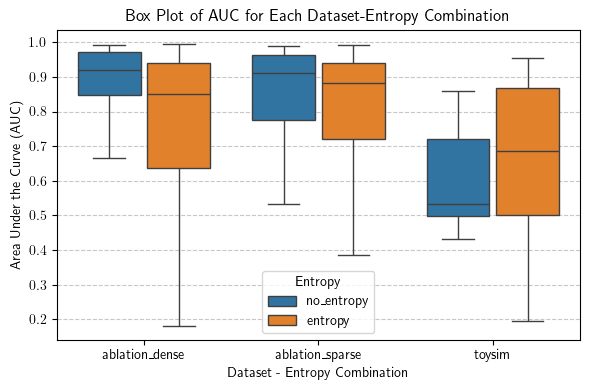

In [257]:
plt.figure(figsize=(6, 4))

print_statistics_entropy(box_plot_dataframe, 'AUC')

sns.boxplot(x='Dataset_Entropy', y="AUC", data=box_plot_dataframe, hue="Entropy", showfliers=False, dodge=True, gap=0.1)

# Improve readability
# plt.xticks(ha="right")
plt.xlabel("Dataset - Entropy Combination")
plt.ylabel("Area Under the Curve (AUC)")
plt.title("Box Plot of AUC for Each Dataset-Entropy Combination")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.savefig("exp1_auc_boxplot.svg")
plt.show()

---
### Pairplots for the parameters across each dataset based on NLL and AUC
---

In [258]:
# Print the columns available in all data frames
print(data_frames["ablation_dense"]["no_entropy"].columns)
print(data_frames["ablation_sparse"]["no_entropy"].columns)
print(data_frames["toysim"]["no_entropy"].columns)
print(data_frames["ablation_dense"]["entropy"].columns)
print(data_frames["ablation_sparse"]["entropy"].columns)
print(data_frames["toysim"]["entropy"].columns)

Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'axis_resolution', 'vector_length_scale', 'vector_dimensionality'],
      dtype='object')
Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'axis_resolution', 'vector_length_scale', 'vector_dimensionality'],
      dtype='object')
Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'vector_length_scale', 'vector_dimensionality'],
      dtype='object')
Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'decoding_disk_radii_1', 'decoding_disk_radii_2', 'axis_resolution',
       'vector_length_scale', 'vector_dimensionality'],
      dtype='object')
Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'decoding_disk_radii_1', 'decoding_disk_radii_2', 'axis_resolution',
       'vector_length_scale', 'vector_dimensionality'],
      dtype='object')
Index(['Unnamed: 0', 'test_nll', 'test_auc', 'decoding_method',
       'decoding_disk_radii_1', 'dec

---
### Functions to visualize data
---

In [259]:
def print_statistics(df: pd.DataFrame, metric: str):
    summary_stats = df.groupby('decoding_method')[metric].describe()[['25%', '50%', '75%', 'min', 'max', 'mean', 'std']]
    summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']

    # Reset index for tabulate
    summary_stats.reset_index(inplace=True)

    # Print formatted table
    print(tabulate(summary_stats, headers='keys', tablefmt='pretty', floatfmt=".4f"))

def plot_box_plots(df: pd.DataFrame, title: str, metric: str, y_label: str):
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='decoding_method', y=metric, data=df, hue="entropy", showfliers=False)
    plt.xlabel("Decoding Method")
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{title}.svg")
    plt.show()

---
### Ablation Dense
---

+----+----------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
|    |      decoding_method       |         25%         |         50%         |        75%         |        min         |        max         |        mean         |         std         |         IQR         |
+----+----------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
| 0  |            relu            | 0.30372971964561835 | 0.43250292815628366 | 0.6234966983783404 | 0.2683261806214971 | 0.8386232225952431 | 0.46115972949978445 | 0.16851722735051952 | 0.3197669787327221  |
| 1  |       relu_normalize       | 0.2909033791922493  | 0.4288606607771628  | 0.5852677513531458 | 0.2598897286482554 | 0.8470982311059906 | 0.44695348928302525 |

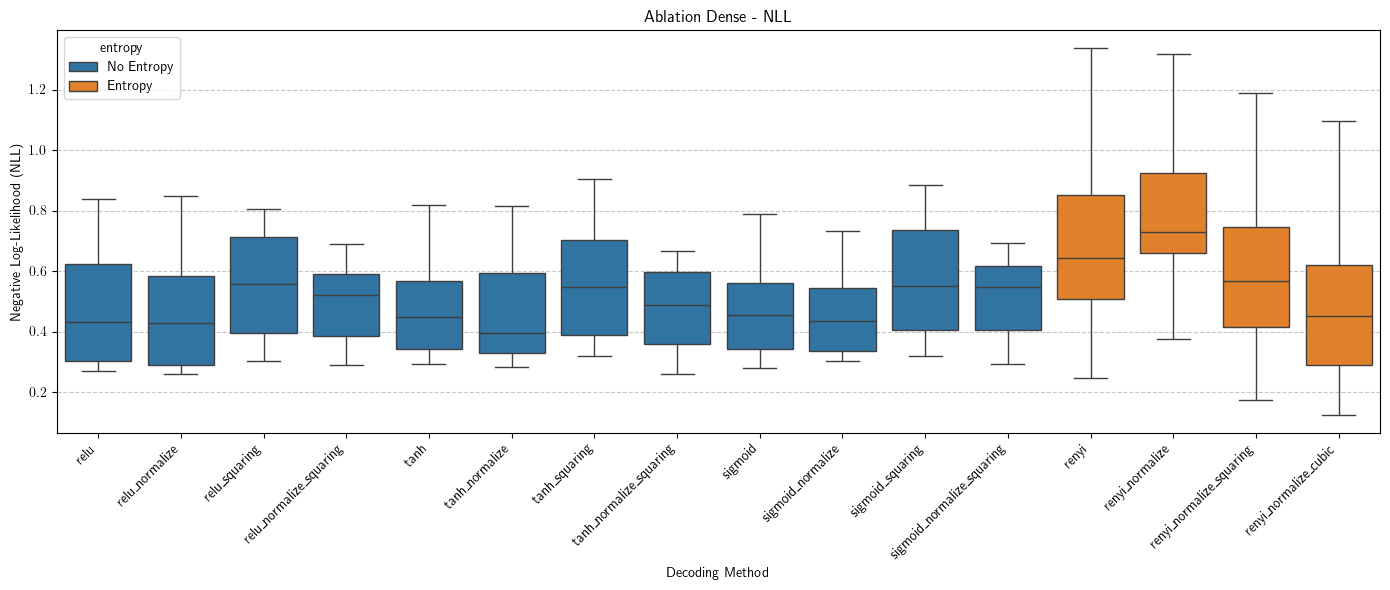

+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
|    |      decoding_method       |        25%         |        50%         |        75%         |        min         |        max         |        mean        |         std         |         IQR         |
+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
| 0  |            relu            | 0.8500668218281979 | 0.9261250864354782 | 0.9707014001972366 | 0.6465969582321491 | 0.9892862733153268 | 0.8907846107384407 | 0.10509291266389523 | 0.12063457836903868 |
| 1  |       relu_normalize       | 0.8476343375091892 | 0.9165193509374954 | 0.974091242580501  | 0.6336128450036009 | 0.9913486000548244 | 0.8919543908637342 | 0.104266141703

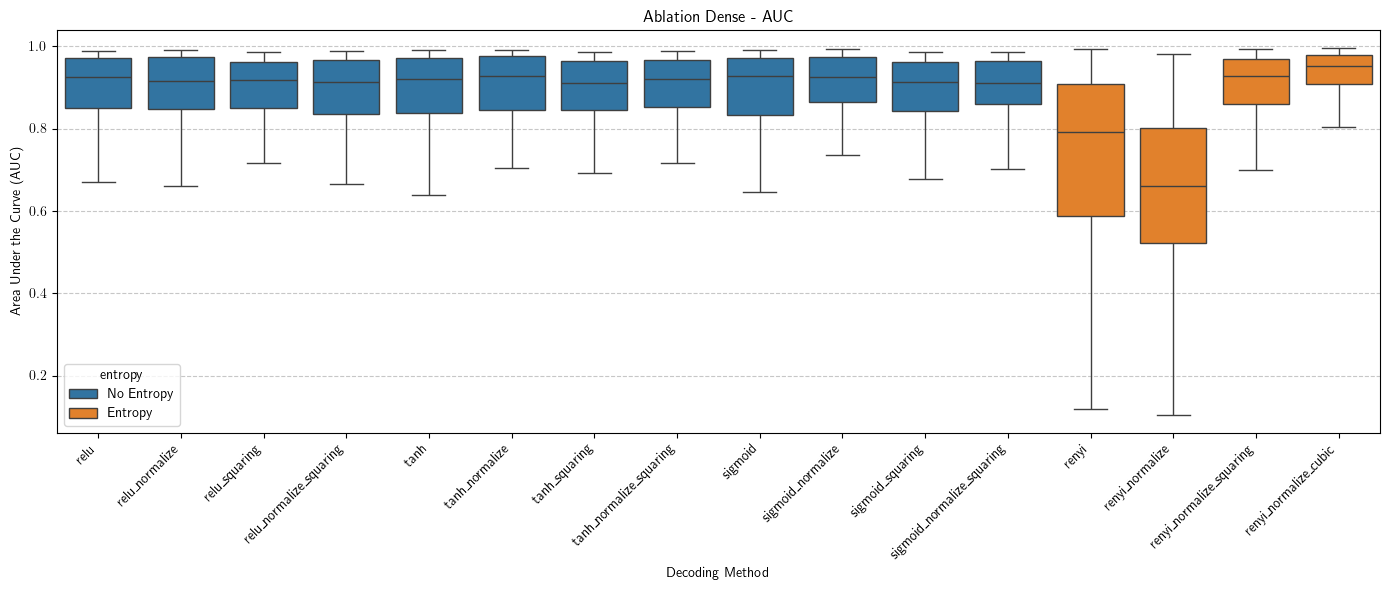

In [260]:
df_combineded = pd.concat([
    data_frames["ablation_dense"]["no_entropy"],
    data_frames["ablation_dense"]["entropy"],
])

# create a flag for entropy
df_combineded["entropy"] = df_combineded["decoding_method"].apply(lambda x: "Entropy" if "renyi" in x else "No Entropy")

# remove renyi_squared and renyi_cubed
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_squaring")]
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_cubic")]

print_statistics(df_combineded, "test_nll")
plot_box_plots(df_combineded, "Ablation Dense - NLL", "test_nll", "Negative Log-Likelihood (NLL)")
print_statistics(df_combineded, "test_auc")
plot_box_plots(df_combineded, "Ablation Dense - AUC", "test_auc", "Area Under the Curve (AUC)")

---
### Ablation Sparse
---

+----+----------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
|    |      decoding_method       |         25%         |         50%         |        75%         |        min         |        max         |        mean         |         std         |         IQR         |
+----+----------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+
| 0  |            relu            | 0.38309946621897617 |  0.469158993088476  | 0.6287822806970614 | 0.3385669167798525 | 0.8599738913629497 |  0.515575697232255  | 0.15697949739906933 | 0.24568281447808527 |
| 1  |       relu_normalize       | 0.3687600490268453  | 0.4771849593844014  | 0.6030982827863745 | 0.3036416668668439 | 0.926030458197383  | 0.5024153184306562  |

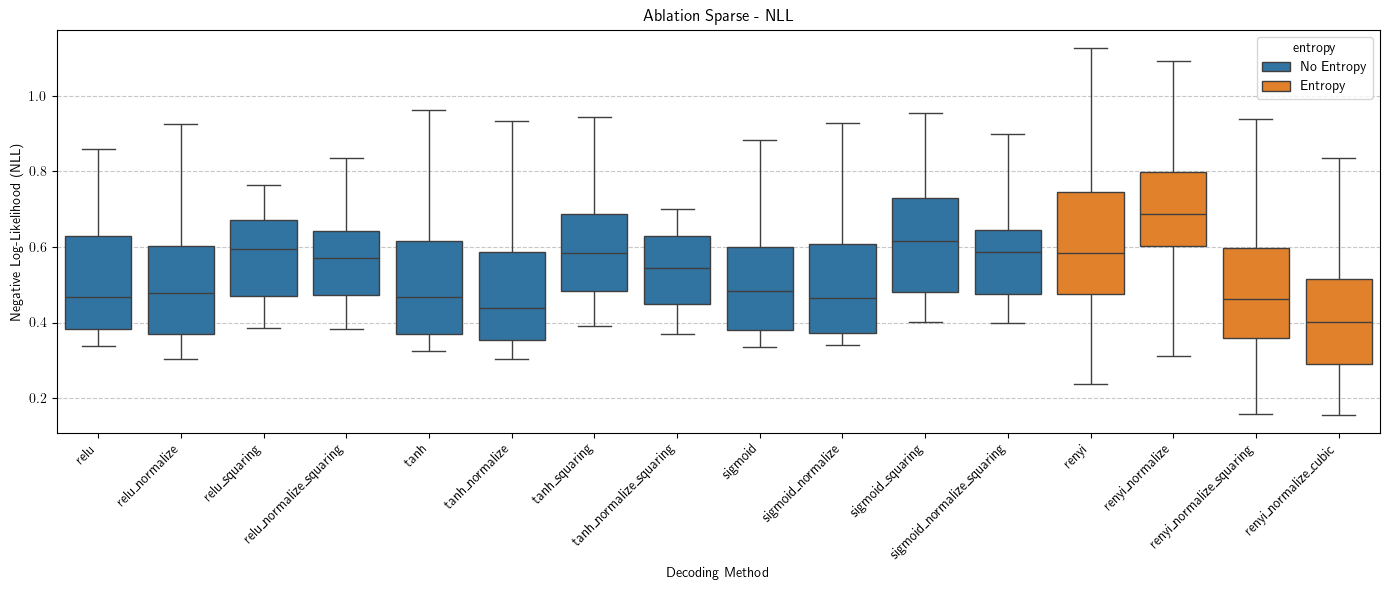

+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
|    |      decoding_method       |        25%         |        50%         |        75%         |        min         |        max         |        mean        |         std         |         IQR         |
+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
| 0  |            relu            | 0.788132075205918  | 0.9119459914948695 | 0.9644939814691179 | 0.5327654051576243 | 0.9849707194735744 | 0.8539546734455398 | 0.14330535849206058 | 0.17636190626319992 |
| 1  |       relu_normalize       | 0.7660982375506036 | 0.911912238091303  | 0.9647287992002324 | 0.5414531963093497 | 0.982189395423636  | 0.8522201022848142 | 0.144306596635

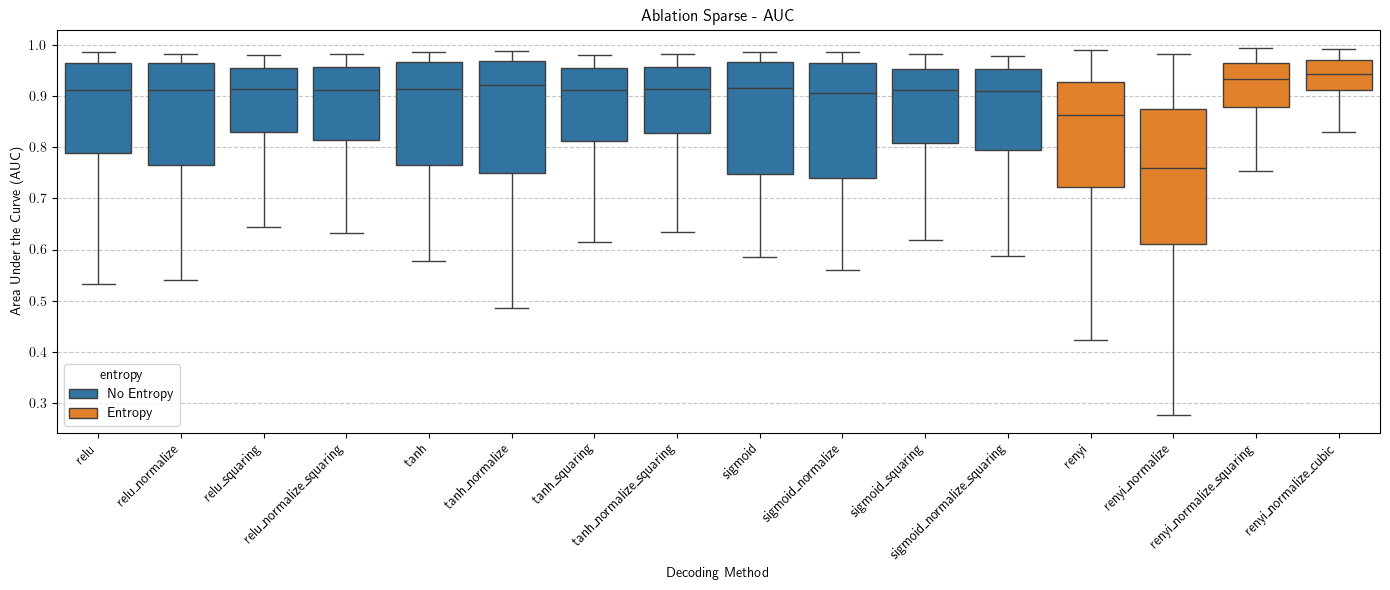

In [261]:
df_combineded = pd.concat([
    data_frames["ablation_sparse"]["no_entropy"],
    data_frames["ablation_sparse"]["entropy"],
])

# create a flag for entropy
df_combineded["entropy"] = df_combineded["decoding_method"].apply(lambda x: "Entropy" if "renyi" in x else "No Entropy")

# remove renyi_squared and renyi_cubed
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_squaring")]
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_cubic")]

print_statistics(df_combineded, "test_nll")
plot_box_plots(df_combineded, "Ablation Sparse - NLL", "test_nll", "Negative Log-Likelihood (NLL)")
print_statistics(df_combineded, "test_auc")
plot_box_plots(df_combineded, "Ablation Sparse - AUC", "test_auc", "Area Under the Curve (AUC)")

---
### ToySim
---

+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+----------------------+
|    |      decoding_method       |        25%         |        50%         |        75%         |        min         |        max         |        mean        |         std          |         IQR          |
+----+----------------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+----------------------+
| 0  |            relu            | 0.6514041229700657 | 0.6889271460537241 | 0.7112713852490635 | 0.5775963896681557 | 0.7380332935707565 | 0.6731730622110721 | 0.05391196297184262  | 0.05986726227899786  |
| 1  |       relu_normalize       | 0.6528569934825271 | 0.7115369392416446 | 0.7334110261044853 | 0.5863384302339195 | 0.7568375501271403 | 0.6887221555935565 | 0.0648

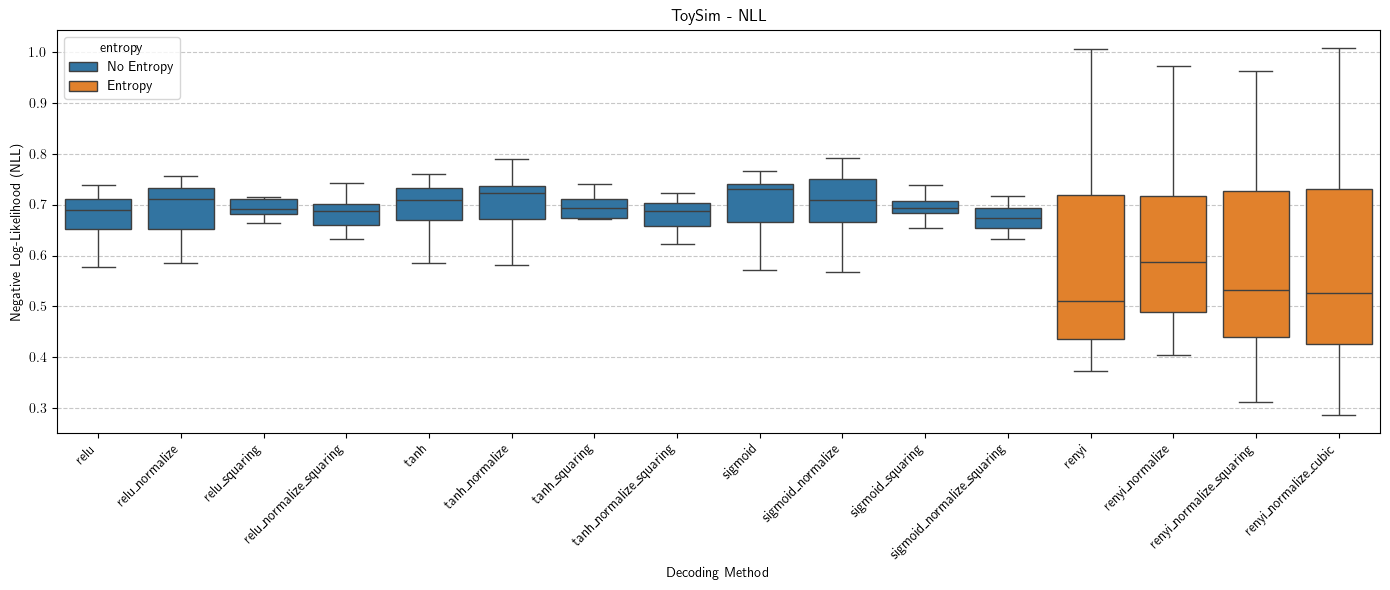

+----+----------------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
|    |      decoding_method       |         25%         |        50%         |        75%         |        min         |        max         |        mean        |         std         |         IQR         |
+----+----------------------------+---------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+---------------------+
| 0  |            relu            | 0.4986157407407407  | 0.5639920634920634 | 0.6751964285714286 | 0.4501878306878307 | 0.8598465608465607 | 0.608733024691358  | 0.14689399122857325 | 0.17658068783068787 |
| 1  |       relu_normalize       | 0.48010185185185184 | 0.540207671957672  | 0.6444345238095238 | 0.4416137566137566 | 0.8220502645502645 | 0.5814583333333335 | 0.1396097

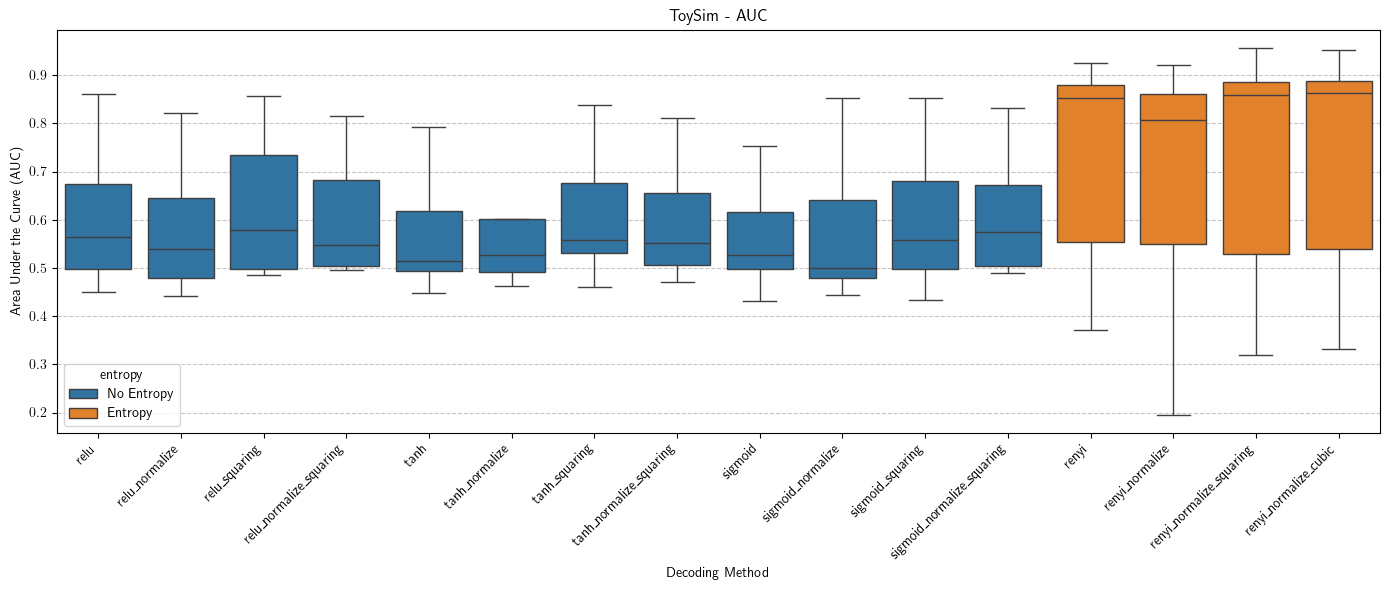

In [262]:
df_combineded = pd.concat([
    data_frames["toysim"]["no_entropy"],
    data_frames["toysim"]["entropy"],
])

# create a flag for entropy
df_combineded["entropy"] = df_combineded["decoding_method"].apply(lambda x: "Entropy" if "renyi" in x else "No Entropy")

# remove renyi_squared and renyi_cubed
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_squaring")]
df_combineded = df_combineded[~(df_combineded["decoding_method"] == "renyi_cubic")]

print_statistics(df_combineded, "test_nll")
plot_box_plots(df_combineded, "ToySim - NLL", "test_nll", "Negative Log-Likelihood (NLL)")
print_statistics(df_combineded, "test_auc")
plot_box_plots(df_combineded, "ToySim - AUC", "test_auc", "Area Under the Curve (AUC)")

---
### Sub-experiment Plots
---

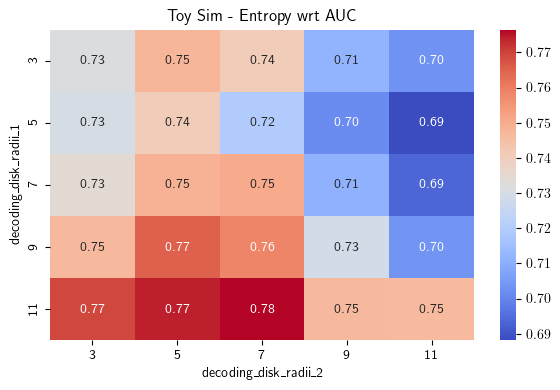

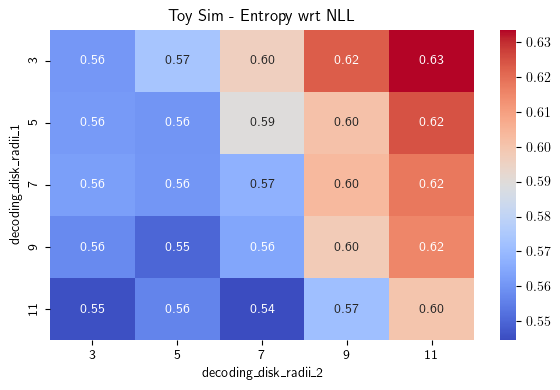

In [263]:
# Toymap - Entropy

# get columns that use normalize entropy
sub_df = data_frames["toysim"]["entropy"]
sub_df = sub_df[sub_df["decoding_method"].str.contains("norm")]
sub_df = sub_df[["test_auc", "test_nll", "decoding_disk_radii_1", "decoding_disk_radii_2"]]

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Toy Sim - Entropy wrt AUC")
plt.tight_layout()
plt.savefig("toy_sim_entropy_heatmap_auc.svg")

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Toy Sim - Entropy wrt NLL")
plt.tight_layout()
plt.savefig("toy_sim_entropy_heatmap_nll.svg")

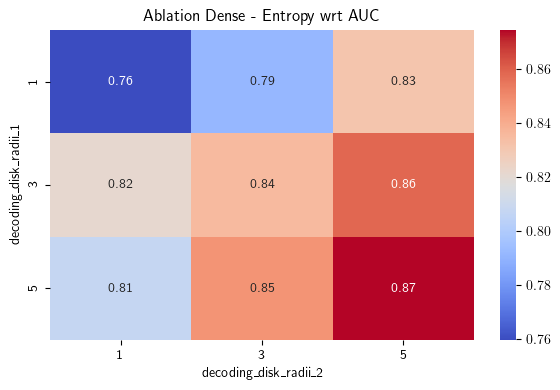

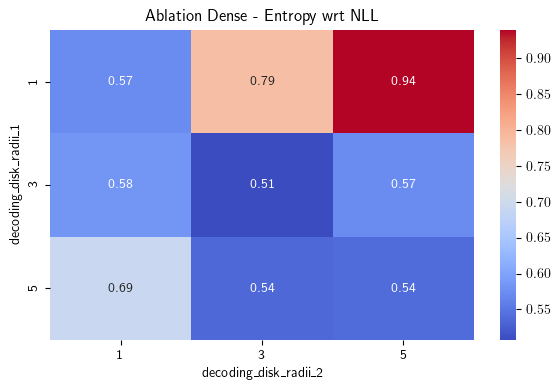

In [264]:
# Ablation - Dense
sub_df = data_frames["ablation_dense"]["entropy"]
sub_df = sub_df[sub_df["decoding_method"].str.contains("norm")]
sub_df = sub_df[["test_auc", "test_nll", "decoding_disk_radii_1", "decoding_disk_radii_2"]]

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Dense - Entropy wrt AUC")
plt.tight_layout()
plt.savefig("ablation_dense_entropy_heatmap_auc.svg")

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Dense - Entropy wrt NLL")
plt.tight_layout()
plt.savefig("ablation_dense_entropy_heatmap_nll.svg")

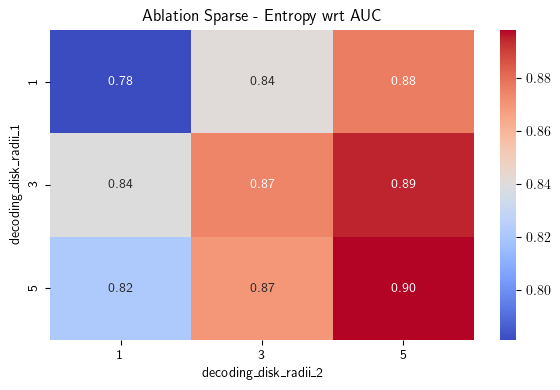

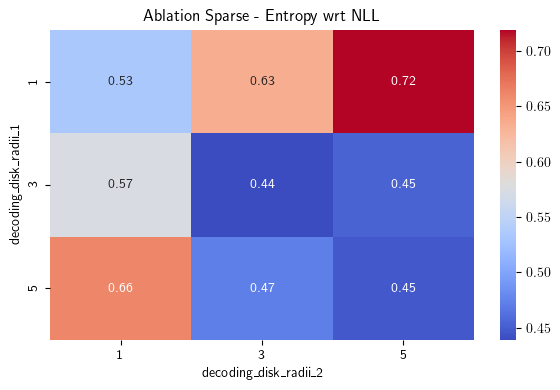

In [265]:
# Ablation - Sparse
sub_df = data_frames["ablation_sparse"]["entropy"]
sub_df = sub_df[sub_df["decoding_method"].str.contains("norm")]
sub_df = sub_df[["test_auc", "test_nll", "decoding_disk_radii_1", "decoding_disk_radii_2"]]

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Sparse - Entropy wrt AUC")
plt.tight_layout()
plt.savefig("ablation_sparse_entropy_heatmap_auc.svg")

pivot_df = sub_df.pivot_table(index="decoding_disk_radii_1", columns="decoding_disk_radii_2", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Sparse - Entropy wrt NLL")
plt.tight_layout()
plt.savefig("ablation_sparse_entropy_heatmap_nll.svg")

---
### Vector Dimensionality
---

Text(0.5, 1.0, 'Ablation Dense wrt NLL')

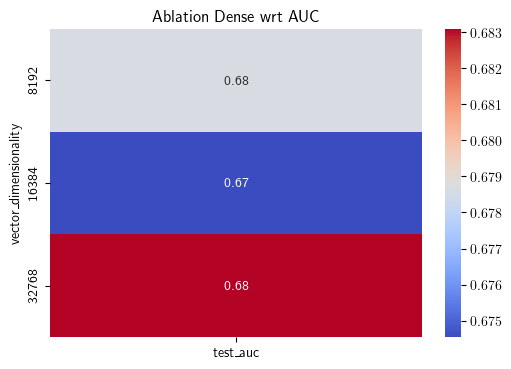

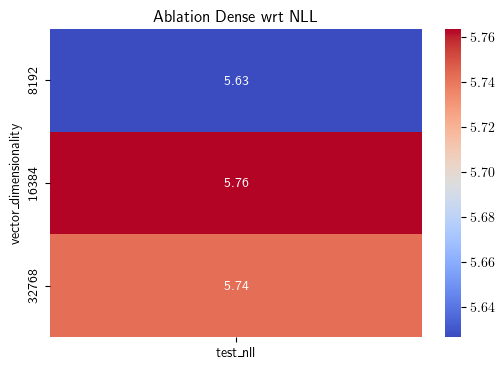

In [266]:
# Ablation Dense
df_combineded = pd.concat([
    data_frames["ablation_dense"]["no_entropy"],
    data_frames["ablation_dense"]["entropy"],
])
df_combineded = df_combineded[df_combineded["decoding_method"].str.contains("norm")]
df_combineded = df_filtered[["test_auc", "test_nll", "vector_dimensionality"]]

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Dense wrt AUC")

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Dense wrt NLL")

Text(0.5, 1.0, 'Ablation Sparse wrt NLL')

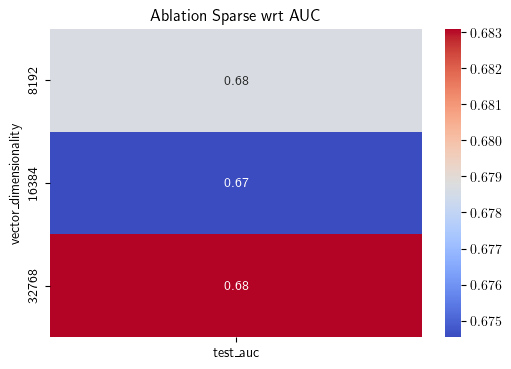

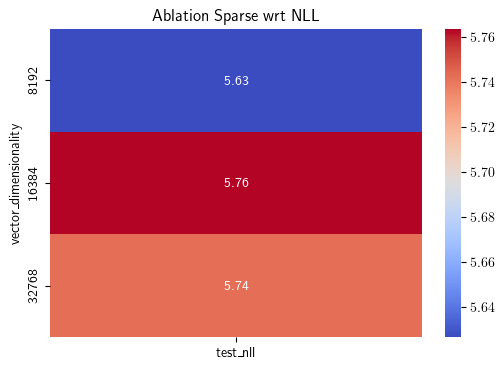

In [267]:
# Ablation Sparse
df_combineded = pd.concat([
    data_frames["ablation_sparse"]["no_entropy"],
    data_frames["ablation_sparse"]["entropy"],
])
df_combineded = df_combineded[df_combineded["decoding_method"].str.contains("norm")]
df_combineded = df_filtered[["test_auc", "test_nll", "vector_dimensionality"]]

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Sparse wrt AUC")

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Ablation Sparse wrt NLL")

Text(0.5, 1.0, 'Toy Sim wrt NLL')

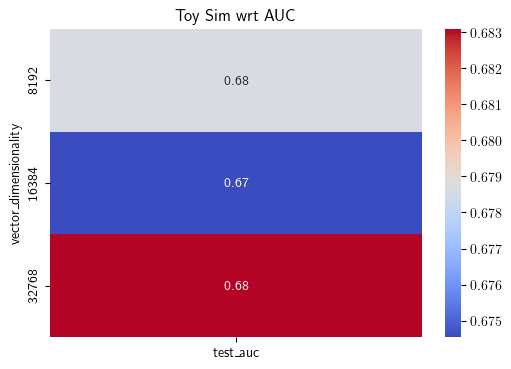

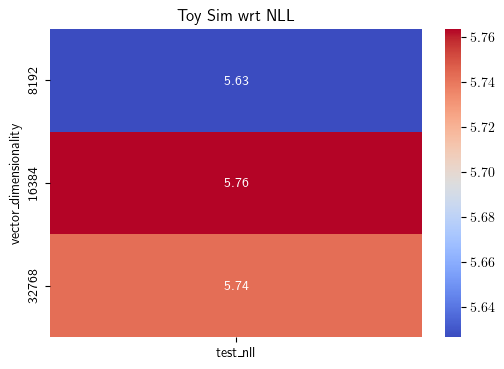

In [268]:
# Toy Sim
df_combineded = pd.concat([
    data_frames["toysim"]["no_entropy"],
    data_frames["toysim"]["entropy"],
])
df_combineded = df_combineded[df_combineded["decoding_method"].str.contains("norm")]
df_combineded = df_filtered[["test_auc", "test_nll", "vector_dimensionality"]]

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_auc")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Toy Sim wrt AUC")

pivot_df = df_combineded.pivot_table(index="vector_dimensionality", values="test_nll")

plt.figure(figsize=(6, 4))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Toy Sim wrt NLL")

---
### Best Performing Configurations
---

In [ ]:
top_10 = data_frames["ablation_dense"]["entropy"].sort_values(by="test_auc", ascending=False).head(10)
print(top_10)

     Unnamed: 0  test_nll  test_auc        decoding_method  \
100         100  0.263650  0.995108  renyi_normalize_cubic   
158         158  0.152016  0.995091  renyi_normalize_cubic   
371         371  0.630607  0.994876  renyi_normalize_cubic   
160         160  0.135360  0.994533  renyi_normalize_cubic   
320         320  0.202934  0.994442  renyi_normalize_cubic   
374         374  0.147486  0.994404  renyi_normalize_cubic   
373         373  0.136204  0.994330  renyi_normalize_cubic   
103         103  0.140740  0.994320  renyi_normalize_cubic   
377         377  0.133375  0.994270  renyi_normalize_cubic   
157         157  0.136411  0.994133  renyi_normalize_cubic   

     decoding_disk_radii_1  decoding_disk_radii_2  axis_resolution  \
100                      1                      3              0.1   
158                      3                      5              0.1   
371                      1                      5              0.1   
160                      5           

In [271]:
top_10 = data_frames["ablation_sparse"]["entropy"].sort_values(by="test_auc", ascending=False).head(10)
print(top_10)

     Unnamed: 0  test_nll  test_auc           decoding_method  \
93           93  0.157292  0.993360  renyi_normalize_squaring   
48           48  0.245532  0.991637     renyi_normalize_cubic   
533         533  0.240254  0.991629     renyi_normalize_cubic   
535         535  0.191616  0.990527     renyi_normalize_cubic   
91           91  0.270809  0.990254  renyi_normalize_squaring   
102         102  0.163616  0.990083     renyi_normalize_cubic   
39           39  0.231926  0.989432  renyi_normalize_squaring   
315         315  0.193154  0.989115     renyi_normalize_cubic   
58           58  0.237075  0.989029                     renyi   
307         307  0.354050  0.988973  renyi_normalize_squaring   

     decoding_disk_radii_1  decoding_disk_radii_2  axis_resolution  \
93                       3                      1              0.1   
48                       3                      1              0.1   
533                      1                      5              0.1   
535 

In [272]:
top_10 = data_frames["toysim"]["entropy"].sort_values(by="test_auc", ascending=False).head(10)
print(top_10)

      Unnamed: 0  test_nll  test_auc           decoding_method  \
1002        1002  0.346249  0.955825  renyi_normalize_squaring   
277          277  0.302121  0.952676     renyi_normalize_cubic   
1026        1026  0.303664  0.949401     renyi_normalize_cubic   
125          125  0.287300  0.947795     renyi_normalize_cubic   
875          875  0.321255  0.946815     renyi_normalize_cubic   
275          275  0.288952  0.946700     renyi_normalize_cubic   
1025        1025  0.295712  0.946554     renyi_normalize_cubic   
1152        1152  0.323294  0.945063  renyi_normalize_squaring   
276          276  0.297117  0.944479     renyi_normalize_cubic   
100          100  0.319843  0.941956  renyi_normalize_squaring   

      decoding_disk_radii_1  decoding_disk_radii_2  vector_length_scale  \
1002                      3                      7                  2.0   
277                       3                      7                  1.5   
1026                      3                     